
<div style="
    background-color: #f7f7f7;
    background-image: url(''), url('') ;
    background-position: left bottom, right top;
    background-repeat: no-repeat,  no-repeat;
    background-size: auto 60px, auto 160px;
    border-radius: 5px;
    box-shadow: 0px 3px 1px -2px rgba(0, 0, 0, 0.2), 0px 2px 2px 0px rgba(0, 0, 0, 0.14), 0px 1px 5px 0px rgba(0,0,0,.12);">

<h1 style="
    color: #2a4cdf;
    font-style: normal;
    font-size: 2.25rem;
    line-height: 1.4em;
    font-weight: 600;
    padding: 30px 200px 0px 30px;"> 
        Perovscribe Evals</h1>

<p style="
    line-height: 1.4em;
    padding: 30px 200px 0px 30px;">
    This notebook runs through the analysis of the Perovscribe extraction pipeline.
</p>

<p style="font-size: 1.25em; font-style: italic; padding: 5px 200px 30px 30px;">
     Sherjeel Shabih, Hampus Näsström, Kevin Jablonka and Pepe Márquez
</p>
</div>

### Load theme

In [ ]:
from plotly_theme import register_template, scatter_plot, set_defaults   
register_template()
set_defaults()

### Load .env file
You need to add your OPENAI_API_KEY and ANTHROPIC_API_KEY

Or copy paste them in the code below

In [ ]:
from dotenv import load_dotenv

load_dotenv();

In [ ]:
# import os

# # Replace 'YOUR_API_KEY_HERE' with your actual OpenAI API key
# os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY_HERE"

### Imports

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
from math import pi
import os
import json
from pathlib import Path

from perovscribe.pipeline import ExtractionPipeline


## Setup Cache for LiteLLM
src/perovscribe/llm.py

litellm.cache = Cache(
    type="redis",
    host="127.0.0.1",
    port=6379,
    ttl=1000000,
    # password="foobared",
    namespace="litellm",
)

## Calculate all model metrics from data

### Evaluate all models

In [4]:
EXTRACTIONS_DIR = Path("data/extractions")
GROUND_TRUTH_DIR = Path("data/15_selected_papers")

all_metrics = {}  # model_name -> paper_doi -> {field: score}
all_precs_and_recalls = {}

for model_dir in EXTRACTIONS_DIR.iterdir():
    if not model_dir.is_dir():
        continue
    
    model_name = model_dir.name
    print(f"Evaluating model: {model_name}")
    model_metrics = {}


    pipeline = ExtractionPipeline(model_name=model_name, preprocessor="pymupdf", postprocessor="NONE", cache_dir="", use_cache=True)
    model_metrics, avg_recalls, avg_precisions = pipeline._evaluate_multiple(model_dir, GROUND_TRUTH_DIR)


    all_precs_and_recalls[model_name] = {"precision": avg_precisions, "recall":avg_recalls}
    all_metrics[model_name] = model_metrics

# Mapping to readable names
model_name_map = {
    "claude-opus-4-1-20250805": "Claude Opus 4.1",
    "claude-opus-4-20250514": "Claude Opus 4",
    "claude-sonnet-4-20250514": "Claude Sonnet 4",
    "gpt-4.1-2025-04-14": "GPT-4.1",
    "gpt-4o-2024-08-06": "GPT-4o",
    "gpt-5-2025-08-07": "GPT-5",
    "gpt-5-mini-2025-08-07": "GPT-5 Mini"
}

# Apply the mapping
all_metrics_renamed = {
    model_name_map.get(k, k): v for k, v in all_metrics.items()
}
all_metrics = all_metrics_renamed

Evaluating model: gpt-4.1-2025-04-14
Error converting 35.0 wt%: 'wt' is not defined in the unit registry
Error converting 35.0 wt%: 'wt' is not defined in the unit registry
Error converting 5 wt%: 'wt' is not defined in the unit registry
Error converting 5 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 

/tmp/ipykernel_186619/1751991846.py:25: RuntimeWarning:

Mean of empty slice



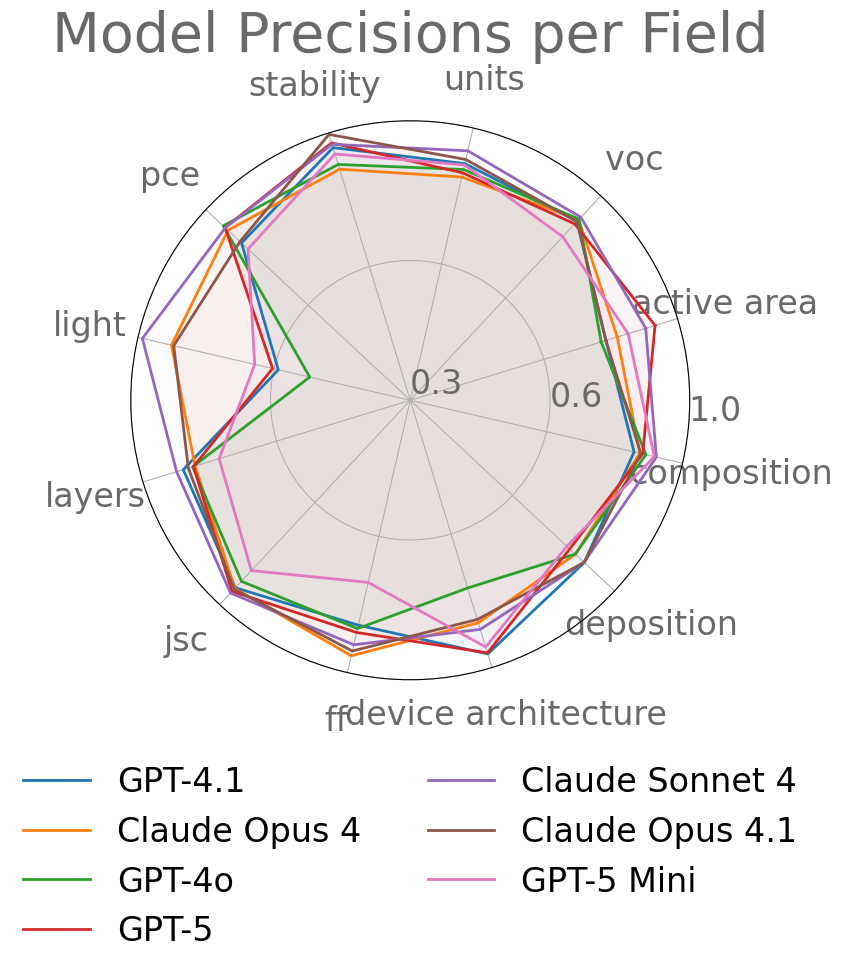

In [5]:
def calculate_aggs_precs(metrics_dict):
    aggregated = {}
    for model in metrics_dict:
        aggregated[model] = {}
        for paper, metrics in metrics_dict[model].items():
            result = {}
            for key, vals in metrics.items():
                tp, fp, fn = vals.get("TP", 0.0), vals.get("FP", 0.0), vals.get("FN", 0.0)
                result[key] = tp / (tp + fp) if tp + fp > 0 else np.nan

            # Aggregation groups
            aggregations = {
                "units": lambda k: k.endswith(":unit"),
                "composition": lambda k: "composition" in k.lower(),
                "stability": lambda k: "stability" in k.lower(),
                "deposition": lambda k: "deposition" in k.lower(),
                "layers": lambda k: "layers" in k.lower(),
                "light": lambda k: "light" in k.lower(),
            }

            aggregated[model][paper] = {}
            for label, condition in aggregations.items():
                values = [v for k, v in result.items() if condition(k)]
                if values:
                    aggregated[model][paper][label] = np.nanmean(values)

            # Add remaining keys
            excluded_keys = {k for group in aggregations.values() for k in result if group(k)}
            for k, v in result.items():
                if k not in excluded_keys and not any(
                    x in k for x in ["averaged_quantities", "number_devices", "encapsulated"]
                ):
                    clean_key = k.replace("_", " ").split(":value")[0]
                    aggregated[model][paper][clean_key] = v

    return aggregated

aggregated_precisions = calculate_aggs_precs(all_metrics)

# Extract all fields
fields = set()
for precs in aggregated_precisions.values():
    for paper_metrics in precs.values():
        fields.update(paper_metrics.keys())
fields = sorted(fields)

# Map model -> average score per field
model_scores = {}
for model_name, precs in aggregated_precisions.items():
    field_totals = {field: [] for field in fields}
    
    for paper_metrics in precs.values():
        for field in fields:
            value = paper_metrics.get(field)
            if value is not None:
                field_totals[field].append(float(value))  # convert from str if needed

    # Replace NaNs with 0.0 for plotting
    field_avgs = [
        np.nanmean(field_totals[field]) if field_totals[field] else 0.0
        for field in fields
    ]
    model_scores[model_name] = field_avgs

# Setup radar plot
num_fields = len(fields)
angles = [n / float(num_fields) * 2 * pi for n in range(num_fields)]
angles += angles[:1]  # loop back

fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

for model_name, scores in model_scores.items():
    values = scores + [scores[0]]  # close the circle
    line, = ax.plot(angles, values, label=model_name, linewidth=2)

    # Use the same color as the line for the fill
    ax.fill(angles, values, color=line.get_color(), alpha=0.03)

# Customize ticks and labels
ax.set_ylim(0.3, 1)

# Set thetagrids instead of xticks for more control
angle_degrees = [a * 180 / np.pi for a in angles[:-1]]
ax.set_thetagrids(angle_degrees, labels=fields)

# Move x-tick (field) labels outward
ax.tick_params(axis='x', pad=25)  # <<< move labels further out

# Style field labels
for label in ax.get_xticklabels():
    label.set_fontsize(24)
    label.set_color("dimgray")
    label.set_rotation(45)
    label.set_horizontalalignment("center")

# Style radial ticks (y-axis)
ax.set_yticks(np.linspace(0.3, 1, 3))
ax.set_yticklabels([f"{y:.1f}" for y in np.linspace(0.3, 1, 3)], fontsize=24, color="dimgray")

# Rotate the plot 30 degrees clockwise
ax.set_theta_offset(np.deg2rad(17))
ax.set_theta_direction(-1)

# Title and legend
plt.title("Model Precisions per Field", size=40, color="dimgray")

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    fontsize=24,
    ncol=2,
    frameon=False
)

plt.tight_layout()
# plt.savefig("plots/model_precisions_spider.pdf")
plt.show()

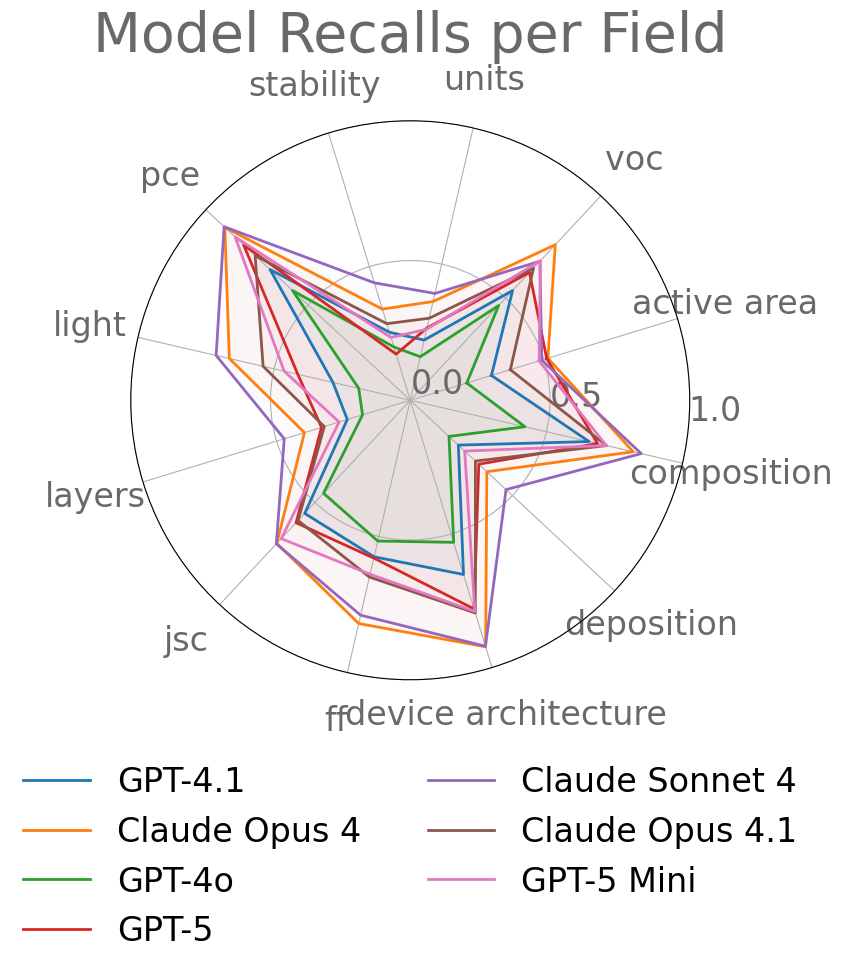

In [6]:

def calculate_and_aggregate(metrics_dict, compute_recall=True):
    aggregated = {}
    for model in metrics_dict:
        aggregated[model] = {}
        for paper, metrics in metrics_dict[model].items():
            result = {}
            for key, vals in metrics.items():
                tp, fp, fn = vals.get("TP", 0.0), vals.get("FP", 0.0), vals.get("FN", 0.0)
                if compute_recall:
                    result[key] = tp / (tp + fn) if tp + fn > 0 else np.nan
                else:
                    result[key] = tp / (tp + fp) if tp + fp > 0 else np.nan

            # Aggregation groups
            aggregations = {
                "units": lambda k: k.endswith(":unit"),
                "composition": lambda k: "composition" in k.lower(),
                "stability": lambda k: "stability" in k.lower(),
                "deposition": lambda k: "deposition" in k.lower(),
                "layers": lambda k: "layers" in k.lower(),
                "light": lambda k: "light" in k.lower(),
            }

            aggregated[model][paper] = {}
            for label, condition in aggregations.items():
                values = [v for k, v in result.items() if condition(k)]
                if values:
                    aggregated[model][paper][label] = np.nanmean(values)

            # Add remaining keys
            excluded_keys = {k for group in aggregations.values() for k in result if group(k)}
            for k, v in result.items():
                if k not in excluded_keys and not any(
                    x in k for x in ["averaged_quantities", "number_devices", "encapsulated"]
                ):
                    clean_key = k.replace("_", " ").split(":value")[0]
                    aggregated[model][paper][clean_key] = v

    return aggregated

aggregated_recalls = calculate_and_aggregate(all_metrics)

# Extract all fields
fields = set()
for model_metrics in aggregated_recalls.values():
    for paper_metrics in model_metrics.values():
        fields.update(paper_metrics.keys())
fields = sorted(fields)

# Map model -> average score per field
model_scores = {}
for model_name, model_metrics in aggregated_recalls.items():
    field_totals = {field: [] for field in fields}
    
    for paper_metrics in model_metrics.values():
        for field in fields:
            value = paper_metrics.get(field)
            if value is not None:
                field_totals[field].append(float(value))  # convert from str if needed

    # Replace NaNs with 0.0 for plotting
    field_avgs = [
        np.nanmean(field_totals[field]) if field_totals[field] else 0.0
        for field in fields
    ]
    model_scores[model_name] = field_avgs

# Setup radar plot
num_fields = len(fields)
angles = [n / float(num_fields) * 2 * pi for n in range(num_fields)]
angles += angles[:1]  # loop back

fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

for model_name, scores in model_scores.items():
    values = scores + [scores[0]]  # close the circle
    line, = ax.plot(angles, values, label=model_name, linewidth=2)

    # Use the same color as the line for the fill
    ax.fill(angles, values, color=line.get_color(), alpha=0.03)

# Customize ticks and labels
ax.set_ylim(0.0, 1)

# Set thetagrids instead of xticks for more control
angle_degrees = [a * 180 / np.pi for a in angles[:-1]]
ax.set_thetagrids(angle_degrees, labels=fields)

# Move x-tick (field) labels outward
ax.tick_params(axis='x', pad=25)  # <<< move labels further out

# Style field labels
for label in ax.get_xticklabels():
    label.set_fontsize(24)
    label.set_color("dimgray")
    label.set_rotation(45)
    label.set_horizontalalignment("center")

# Style radial ticks (y-axis)
ax.set_yticks(np.linspace(0.0, 1, 3))
ax.set_yticklabels([f"{y:.1f}" for y in np.linspace(0.0, 1, 3)], fontsize=24, color="dimgray")

# Rotate the plot 30 degrees clockwise
ax.set_theta_offset(np.deg2rad(17))
ax.set_theta_direction(-1)

# Title and legend
plt.title("Model Recalls per Field", size=40, color="dimgray")

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    fontsize=24,
    ncol=2,
    frameon=False
)

plt.tight_layout()
# plt.savefig("plots/model_recalls_spider.pdf")
plt.show()

{'GPT-4.1': {'precision': 0.8999507146377526, 'recall': 0.27171271266306235}}
{'Claude Opus 4': {'precision': 0.9156687128912147, 'recall': 0.4565021071643588}}
{'GPT-4o': {'precision': 0.8844922232387923, 'recall': 0.1908216136195411}}
{'GPT-5': {'precision': 0.8650115473441109, 'recall': 0.38217437885822153}}
{'Claude Sonnet 4': {'precision': 0.9470132238942088, 'recall': 0.5143394918024667}}
{'Claude Opus 4.1': {'precision': 0.919774011299435, 'recall': 0.32234432234432236}}
{'GPT-5 Mini': {'precision': 0.8367915332126444, 'recall': 0.3066129196856822}}


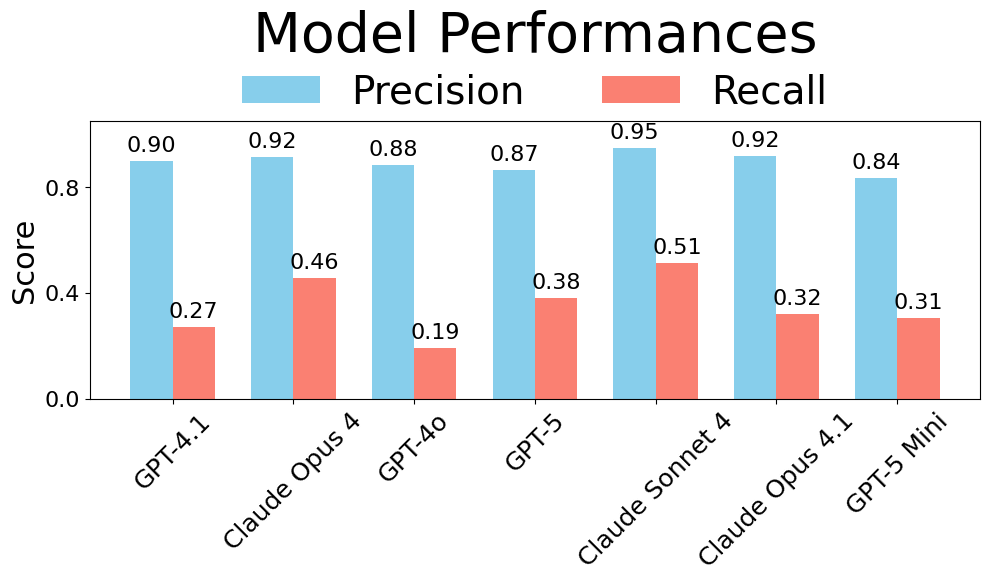

In [7]:
import json
import matplotlib.pyplot as plt
import numpy as np


# Dictionary to store per-model aggregate TP, FP, FN
model_scores = {}

for model_name, model_data in all_metrics.items():
    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0

    for doi_data in model_data.values():
        for value in doi_data.values():
            if isinstance(value, dict):
                total_tp += value.get('TP', 0.0)
                total_fp += value.get('FP', 0.0)
                total_fn += value.get('FN', 0.0)

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else None
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else None

    model_scores[model_name] = {
        'TP': total_tp,
        'FP': total_fp,
        'FN': total_fn,
        'precision': precision,
        'recall': recall
    }
    print({model_name:{'precision': precision, 'recall':recall}})

# Prepare data for plotting
model_names = list(model_scores.keys())
precisions = [model_scores[m]['precision'] for m in model_names]
recalls = [model_scores[m]['recall'] for m in model_names]

# Plot grouped bar chart
x = np.arange(len(model_names))
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, precisions, width, label='Precision', color='skyblue')
rects2 = ax.bar(x + width/2, recalls, width, label='Recall', color='salmon')

# Labels and title
ax.set_ylabel('Score', fontsize=22)
ax.set_title('Model Performances', fontsize=40, pad=50)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, fontsize=18)
ax.set_yticks(np.arange(0, 1.1, 0.4))
ax.set_yticklabels([f"{y:.1f}" for y in np.arange(0, 1.1, 0.4)], fontsize=16)
ax.set_ylim(0, 1.05)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.3),  # below the axes
    ncol=2,                      # ✅ horizontal layout
    fontsize=28,
    frameon=False
)

# Add value labels
def add_labels(rects, values):
    for rect, val in zip(rects, values):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 0.02,
                f'{val:.2f}' if val is not None else 'N/A',
                ha='center', va='bottom', fontsize=16)

add_labels(rects1, precisions)
add_labels(rects2, recalls)

plt.tight_layout()
# plt.savefig("plots/overall_perf.pdf")
plt.show()

In [8]:
import pandas as pd
import plotly.graph_objects as go

# --- Data Definition and Processing (unchanged) ---
tokens_used = {
    "GPT-5 Mini": {
        "Prompt Tokens": 883572,
        "Completion Tokens": 258233,
        "prompt_price": 0.250,
        "output_price": 2.0
    },
    "GPT-5": {
        "Prompt Tokens": 750932,
        "Completion Tokens": 260215,
        "prompt_price": 1.250,
        "output_price": 10.0
    },
    "Claude Opus 4.1": {
        "Prompt Tokens": 695811,
        "Completion Tokens": 128001,
        "prompt_price": 15.0,
        "output_price": 75.0
    },
    "Claude Opus 4": {
        "Prompt Tokens": 1000308,
        "Completion Tokens": 230768,
        "prompt_price": 15.0,
        "output_price": 75.0
    },
    "Claude Sonnet 4": {
        "Prompt Tokens": 889990,
        "Completion Tokens": 174639,
        "prompt_price": 3.0,
        "output_price": 15.0
    },
    "GPT-4.1": {
        "Prompt Tokens": 750680,
        "Completion Tokens": 54524,
        "prompt_price": 2.0,
        "output_price": 8.0
    },
    "GPT-4o": {
        "Prompt Tokens": 677364,
        "Completion Tokens": 28682,
        "prompt_price": 2.50,
        "output_price": 10.0
    },
}

model_data = []
for model, tokens in tokens_used.items():
    prompt_tokens = tokens["Prompt Tokens"]
    completion_tokens = tokens["Completion Tokens"]
    prompt_price = tokens["prompt_price"]
    output_price = tokens["output_price"]
    total_cost = (prompt_tokens / 1_000_000) * prompt_price + (completion_tokens / 1_000_000) * output_price
    scores = model_scores.get(model, {})
    precision = scores.get("precision", None)
    recall = scores.get("recall", None)
    f1 = (2 * precision * recall) / (precision + recall) if precision and recall else None

    model_data.append({
        "model": model,
        "cost": round(total_cost, 4),
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

df_data = pd.DataFrame(model_data).dropna(subset=['f1'])

# --- Plotly Conversion with Colors ---

# The best way to get distinct colors and a legend is to iterate and create
# a separate trace for each model.
# A list of colors for the models (7 distinct colors)
MODEL_COLORS = [
    '#1f77b4',  # Muted Blue (GPT-5 Mini)
    '#ff7f0e',  # Orange (GPT-5)
    '#2ca02c',  # Green (Claude Opus 4.1)
    '#d62728',  # Red (Claude Opus 4)
    '#9467bd',  # Purple (Claude Sonnet 4)
    '#8c564b',  # Brown (GPT-4.1)
    '#e377c2',  # Pink (GPT-4o)
]

# --- Plotly Conversion with Custom Colors ---
fig = go.Figure()

# Custom label offsets (The original used manual offsets, Plotly textposition handles this best)

for index, row in df_data.iterrows():
    model = row['model']
    cost = row['cost']
    f1 = row['f1']
    
    # Get a distinct color based on the index
    color = MODEL_COLORS[index % len(MODEL_COLORS)] # Use modulo to safely cycle colors if list is shorter

    # 1. Scatter Trace for the marker
    fig.add_trace(
        go.Scatter(
            x=[cost],
            y=[f1],
            mode='markers',
            name=model, 
            marker=dict(
                size=15,
                opacity=0.8,
                color=color  # <-- THIS IS WHERE THE COLOR IS SET
            ),
            hovertemplate='<b>%{text}</b><br>Cost: $%{x:.4f}<br>F1 Score: %{y:.4f}<extra></extra>',
            text=[model]
        )
    )

    # 2. Text Trace for the label next to the marker
    fig.add_trace(
        go.Scatter(
            x=[cost],
            y=[f1],
            mode='text',
            name=model + ' Label', 
            text=[model],
            textposition='middle right',
            showlegend=False,
            textfont=dict(size=14, color=color), # <-- AND HERE FOR THE LABEL TEXT
            hoverinfo='none'
        )
    )

# Layout and Axis (Unchanged from last version)
fig.update_layout(
    title={
        'text': "Model Performance vs Cost",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title="Total Cost (USD)",
    yaxis_title="F1 Score",
    showlegend=True,
    # height=600,
    # width=900,
    legend=dict(
        orientation="v",       # Vertical legend (default)
        yanchor="middle",      # Anchor the legend box vertically at its middle point
        y=0.5,                 # Place the middle of the legend at the vertical center of the figure
        xanchor="left",        # Anchor the legend box horizontally at its left edge
        x=1.02,                # Place the left edge of the legend 2% past the right edge of the plot
        bgcolor="rgba(255, 255, 255, 0.5)", # Optional: Add a slight background for visibility
        bordercolor="Black",
        borderwidth=1
    )
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(128,128,128,0.5)')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='rgba(128,128,128,0.5)')

fig.show()

In [9]:
import pandas as pd
import plotly.graph_objects as go
import re
from importlib.resources import files


# Load and extract percentiles
# NOTE: The actual file path "src/perovscribe/allowed_journals.csv" needs to be replaced
# with the name of the file you upload, e.g., "allowed_journals.csv"
try:
    # Assuming the file is named 'allowed_journals.csv' when uploaded
    scopus_df = pd.read_csv(files("perovscribe").joinpath("allowed_journals.csv"))
except FileNotFoundError:
    print("Error: The file 'allowed_journals.csv' was not found. Please upload your data file.")
    # Exit or use dummy data if required, but here we just stop and inform the user.
    # For now, we will proceed assuming the file is provided in the execution step.
    # If the user provides the file, the next block will execute it.
    pass


# Check if DataFrame exists before proceeding (if execution were continuous)
# This part is necessary for a complete script but will be handled by the execution block
# if the user provides the file.
# We will assume a successful load and processing for the conversion delivery.

# Process the DataFrame
scopus_df['Percentile'] = scopus_df['Highest percentile'].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
df = scopus_df


# --- Plotly Conversion ---
# Create the Histogram trace
fig = go.Figure(
    data=[
        go.Histogram(
            x=df['Percentile'],
            nbinsx=20, # Equivalent to bins=20
            # Color is omitted as requested
        )
    ]
)

# Set title and axis labels
fig.update_layout(
    title_text="Distribution of Journal Percentile Rankings",
    xaxis_title="Highest Percentile",
    yaxis_title="Number of Journals",
    # All theme/template settings are removed.
)

fig.show()

In [10]:
pipeline = ExtractionPipeline(model_name="random_authors", preprocessor="pymupdf", postprocessor="NONE", cache_dir="", use_cache=True)
print("hello")            
authors_metrics, authors_recalls, authors_precisions = pipeline._evaluate_multiple(Path("data/random_authors_from_15_selected"), GROUND_TRUTH_DIR)

hello
Error converting 35.0 wt%: 'wt' is not defined in the unit registry
Error converting 35.0 wt%: 'wt' is not defined in the unit registry
Error converting 5 wt%: 'wt' is not defined in the unit registry
Error converting 5 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
[Errno 2] No such file or directory: 'data/random_authors_from_15_selected/10.1038--s41467-021-27740-4.json'
[Errno 2] No such file or directory: 'data/random_authors_from_15_selected/10.1002--solr.202300817.json'
[Errno 2] No such file or directory: 'data/random_authors_from_15_selected/10.1126--science.adf0194.json'
[Errno 2] No such file or directory: 'data/random_authors_from_15_selected/10.

In [39]:
json_files = []
for root, dirs, files in os.walk(Path("data/random_authors_from_15_selected")):
    for filename in files:
        if filename.endswith(".json"):
            json_files.append(filename)

author_model_scores = {}

author_model_scores["authors"] = {}
for doi, doi_data in authors_metrics.items():
    if doi not in json_files:
        continue
    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    for value in doi_data.values():
        if isinstance(value, dict):
            total_tp += value.get('TP', 0.0)
            total_fp += value.get('FP', 0.0)
            total_fn += value.get('FN', 0.0)

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else None
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else None
    author_model_scores["authors"][doi] = precision

for model_name, model_data in all_metrics.items():
    author_model_scores[model_name] = {}
    for doi, doi_data in model_data.items():
        if doi not in json_files:
            continue
        
        total_tp = 0.0
        total_fp = 0.0
        total_fn = 0.0
        for value in doi_data.values():
            if isinstance(value, dict):
                total_tp += value.get('TP', 0.0)
                total_fp += value.get('FP', 0.0)
                total_fn += value.get('FN', 0.0)

        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else None
        # recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else None
        author_model_scores[model_name][doi] = precision

    
print(author_model_scores)

{'authors': {'10.1016--j.nanoen.2016.05.023.json': 1.0, '10.1039--c5ta00568j.json': 0.6666666666666666, '10.1016--j.matlet.2016.07.004.json': 0.8837209302325582, '10.1039--c5dt02388b.json': 0.5564516129032258, '10.1002--solr.201900370.json': 0.9512195121951219, '10.1002--adfm.201500335.json': 0.8245614035087719, '10.1039--c7nr04692h.json': 0.9050925925925926, '10.1002--adfm.202212698.json': 0.8144329896907216, '10.1021--acsaem.9b01928.json': 0.7678571428571429, '10.1002--adma.202302143.json': 0.8079470198675497, '10.1016--j.nanoen.2022.107416.json': 0.9431818181818182, '10.1002--solr.202100879.json': 0.9108910891089109, '10.1021--acs.chemmater.8b01521.json': 0.8235294117647058, '10.1002--adfm.201904856.json': 0.8354430379746836}, 'GPT-4.1': {'10.1016--j.nanoen.2016.05.023.json': 0.8344155844155844, '10.1039--c5ta00568j.json': 0.8529411764705882, '10.1016--j.matlet.2016.07.004.json': 0.7928994082840237, '10.1039--c5dt02388b.json': 0.8503937007874016, '10.1002--solr.201900370.json': 0.82

/home/me/Work/perovskite-extraction/.venv/lib/python3.12/site-packages/dabest/plot_tools.py:2592: UserWarning:

7.1% of the points cannot be placed. You might want to decrease the size of the markers.



<Figure size 1000x600 with 0 Axes>

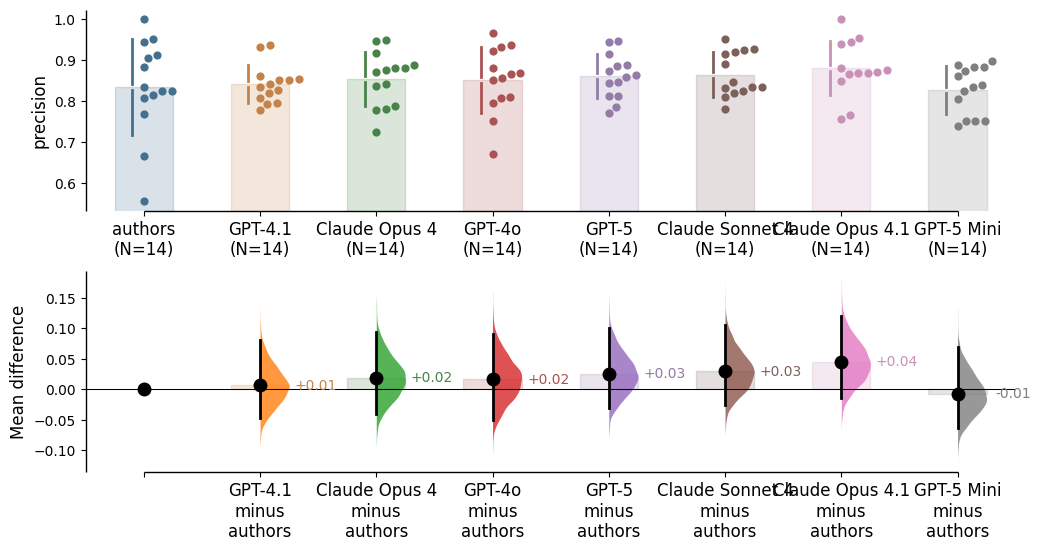

In [40]:
import pandas as pd
import dabest
import matplotlib.pyplot as plt

# Convert your nested dict to a DataFrame
rows = []
for model, dois in author_model_scores.items():
    for doi, precision in dois.items():
        rows.append({'DOI': doi, 'model': model, 'precision': precision})

df = pd.DataFrame(rows)

# Pivot data so each row is a DOI and each column is a model
df_pivot = df.pivot(index='DOI', columns='model', values='precision').reset_index()

# Melt data for dabest
df_melt = df_pivot.melt(id_vars='DOI', var_name='model', value_name='precision')

# Create a dabest object using authors as the control
dabest_data = dabest.load(
    data=df_melt,
    x='model',
    y='precision',
    idx=("authors", "GPT-4.1", "Claude Opus 4", "GPT-4o", "GPT-5",
         "Claude Sonnet 4", "Claude Opus 4.1", "GPT-5 Mini")
)

# Plot mean difference against authors
plt.figure(figsize=(10,6))
dabest_data.mean_diff.plot()
plt.show()
